In [2]:
!pip install prophet

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
    --------------------------------------- 0.3/12.1 MB ? eta -:--:--
    --------------------------------------- 0.3/12.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.1 MB 558.9 kB/s eta 0:00:21
   - -------------------------------------- 0.5/12.1 MB 558.9 kB/s eta 0:00:21
   - -------------------------------------- 0.5/12.1 MB 558.9 kB/s eta 0:00:21
   - -------------------------------------- 0.5/12.1 MB 558.9 kB/s eta 0:00:21
   - -------------------------------------- 0.5/12.1 MB 558.9 kB/s eta 0:00:21
   - -------------------------------------- 0

ERROR: Exception:
Traceback (most recent call last):
  File "C:\Users\AANUOLUWAPO ODUSANWO\anaconda3\Lib\site-packages\pip\_vendor\urllib3\response.py", line 438, in _error_catcher
    yield
  File "C:\Users\AANUOLUWAPO ODUSANWO\anaconda3\Lib\site-packages\pip\_vendor\urllib3\response.py", line 561, in read
    data = self._fp_read(amt) if not fp_closed else b""
           ^^^^^^^^^^^^^^^^^^
  File "C:\Users\AANUOLUWAPO ODUSANWO\anaconda3\Lib\site-packages\pip\_vendor\urllib3\response.py", line 527, in _fp_read
    return self._fp.read(amt) if amt is not None else self._fp.read()
           ^^^^^^^^^^^^^^^^^^
  File "C:\Users\AANUOLUWAPO ODUSANWO\anaconda3\Lib\site-packages\pip\_vendor\cachecontrol\filewrapper.py", line 98, in read
    data: bytes = self.__fp.read(amt)
                  ^^^^^^^^^^^^^^^^^^^
  File "C:\Users\AANUOLUWAPO ODUSANWO\anaconda3\Lib\http\client.py", line 479, in read
    s = self.fp.read(amt)
        ^^^^^^^^^^^^^^^^^
  File "C:\Users\AANUOLUWAPO ODUSANWO\anaco

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from prophet import Prophet

In [5]:
# Load dataset

df = pd.read_csv(r"C:\Users\AANUOLUWAPO ODUSANWO\Downloads\dataset for workshop.csv.xls")

# Display first rows
print(df.head())

         date  temperature_c  humidity_pct  rainfall_mm  disease_cases
0  01/01/2023           22.5            68          2.1             34
1  02/01/2023           22.8            70          0.0             38
2  03/01/2023           23.1            72          5.3             45
3  04/01/2023           22.7            74          8.2             52
4  05/01/2023           23.4            69          1.0             41


## convert to standard date format 

In [6]:
# Convert date column to datetime

df['date'] = pd.to_datetime(df['date'], dayfirst=True)

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           365 non-null    datetime64[ns]
 1   temperature_c  365 non-null    float64       
 2   humidity_pct   365 non-null    int64         
 3   rainfall_mm    365 non-null    float64       
 4   disease_cases  365 non-null    int64         
dtypes: datetime64[ns](1), float64(2), int64(2)
memory usage: 14.4 KB
None


### Describe the dataset

In [8]:
print(df.describe())

                      date  temperature_c  humidity_pct  rainfall_mm  \
count                  365     365.000000    365.000000   365.000000   
mean   2023-07-02 00:00:00      23.243836     74.378082    12.513425   
min    2023-01-01 00:00:00      19.200000     55.000000     0.000000   
25%    2023-04-02 00:00:00      22.100000     65.000000     1.500000   
50%    2023-07-02 00:00:00      23.200000     73.000000     9.000000   
75%    2023-10-01 00:00:00      24.500000     83.000000    20.800000   
max    2023-12-31 00:00:00      26.500000     99.000000    46.500000   
std                    NaN       1.603943     11.389197    12.322242   

       disease_cases  
count     365.000000  
mean      106.526027  
min        28.000000  
25%        46.000000  
50%        79.000000  
75%       147.000000  
max       330.000000  
std        75.475835  


### Visualization

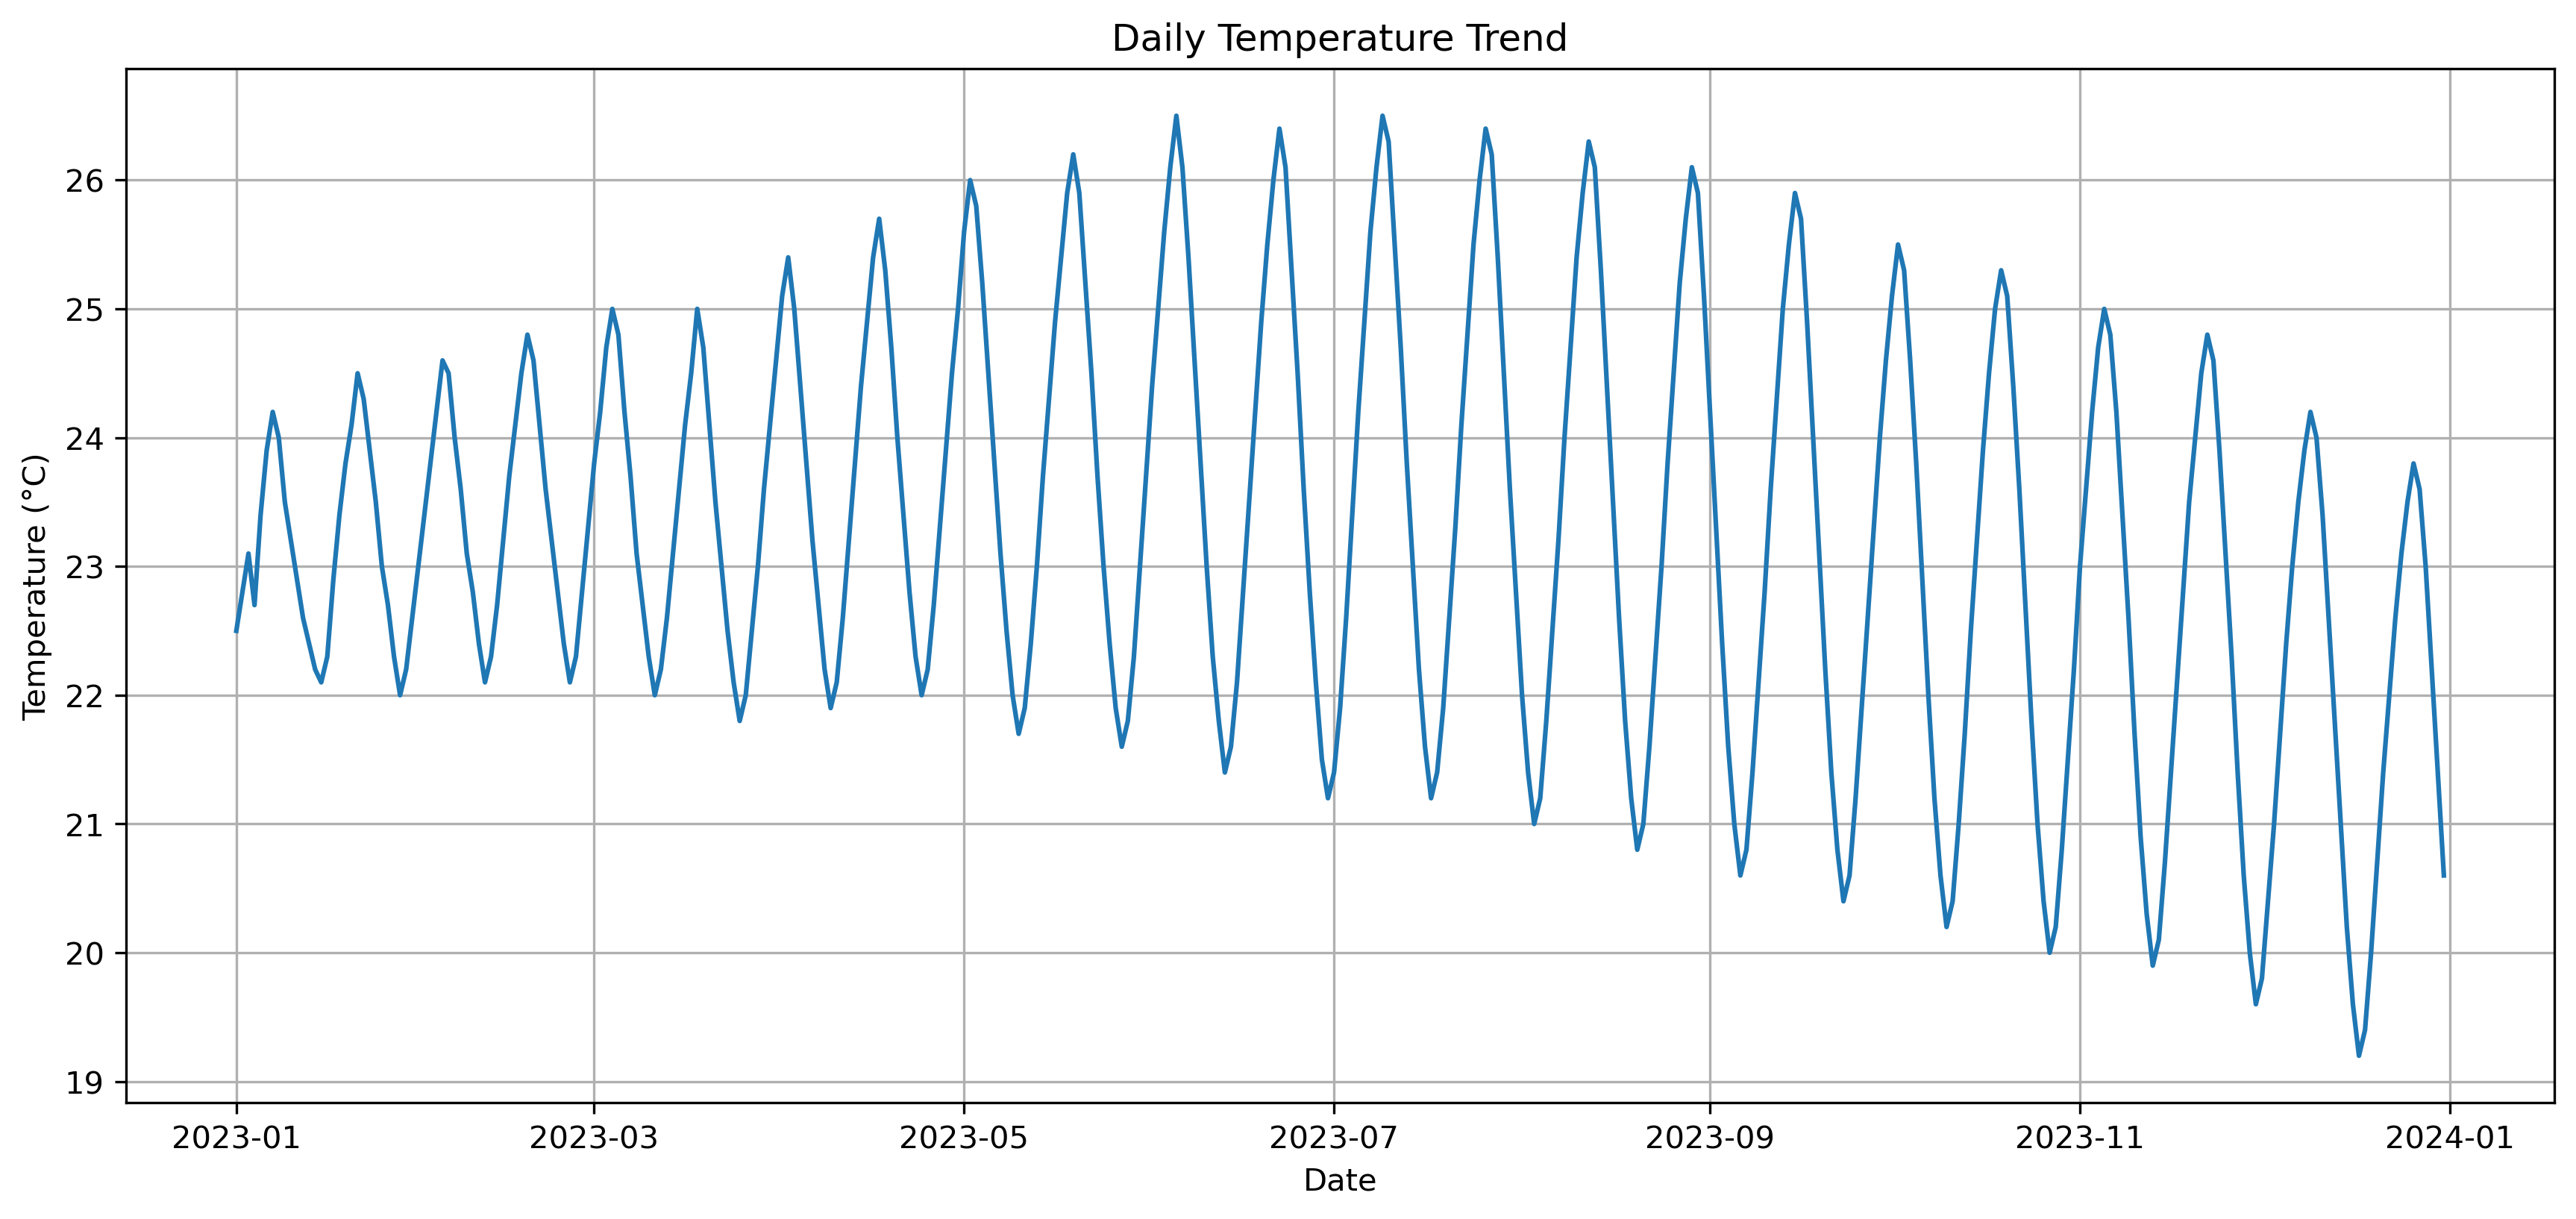

In [9]:
#Temperature Trend Visualization
plt.figure(figsize=(14,6), dpi=300)
plt.plot(df['date'], df['temperature_c'])
plt.title('Daily Temperature Trend')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.grid(True)
plt.show()

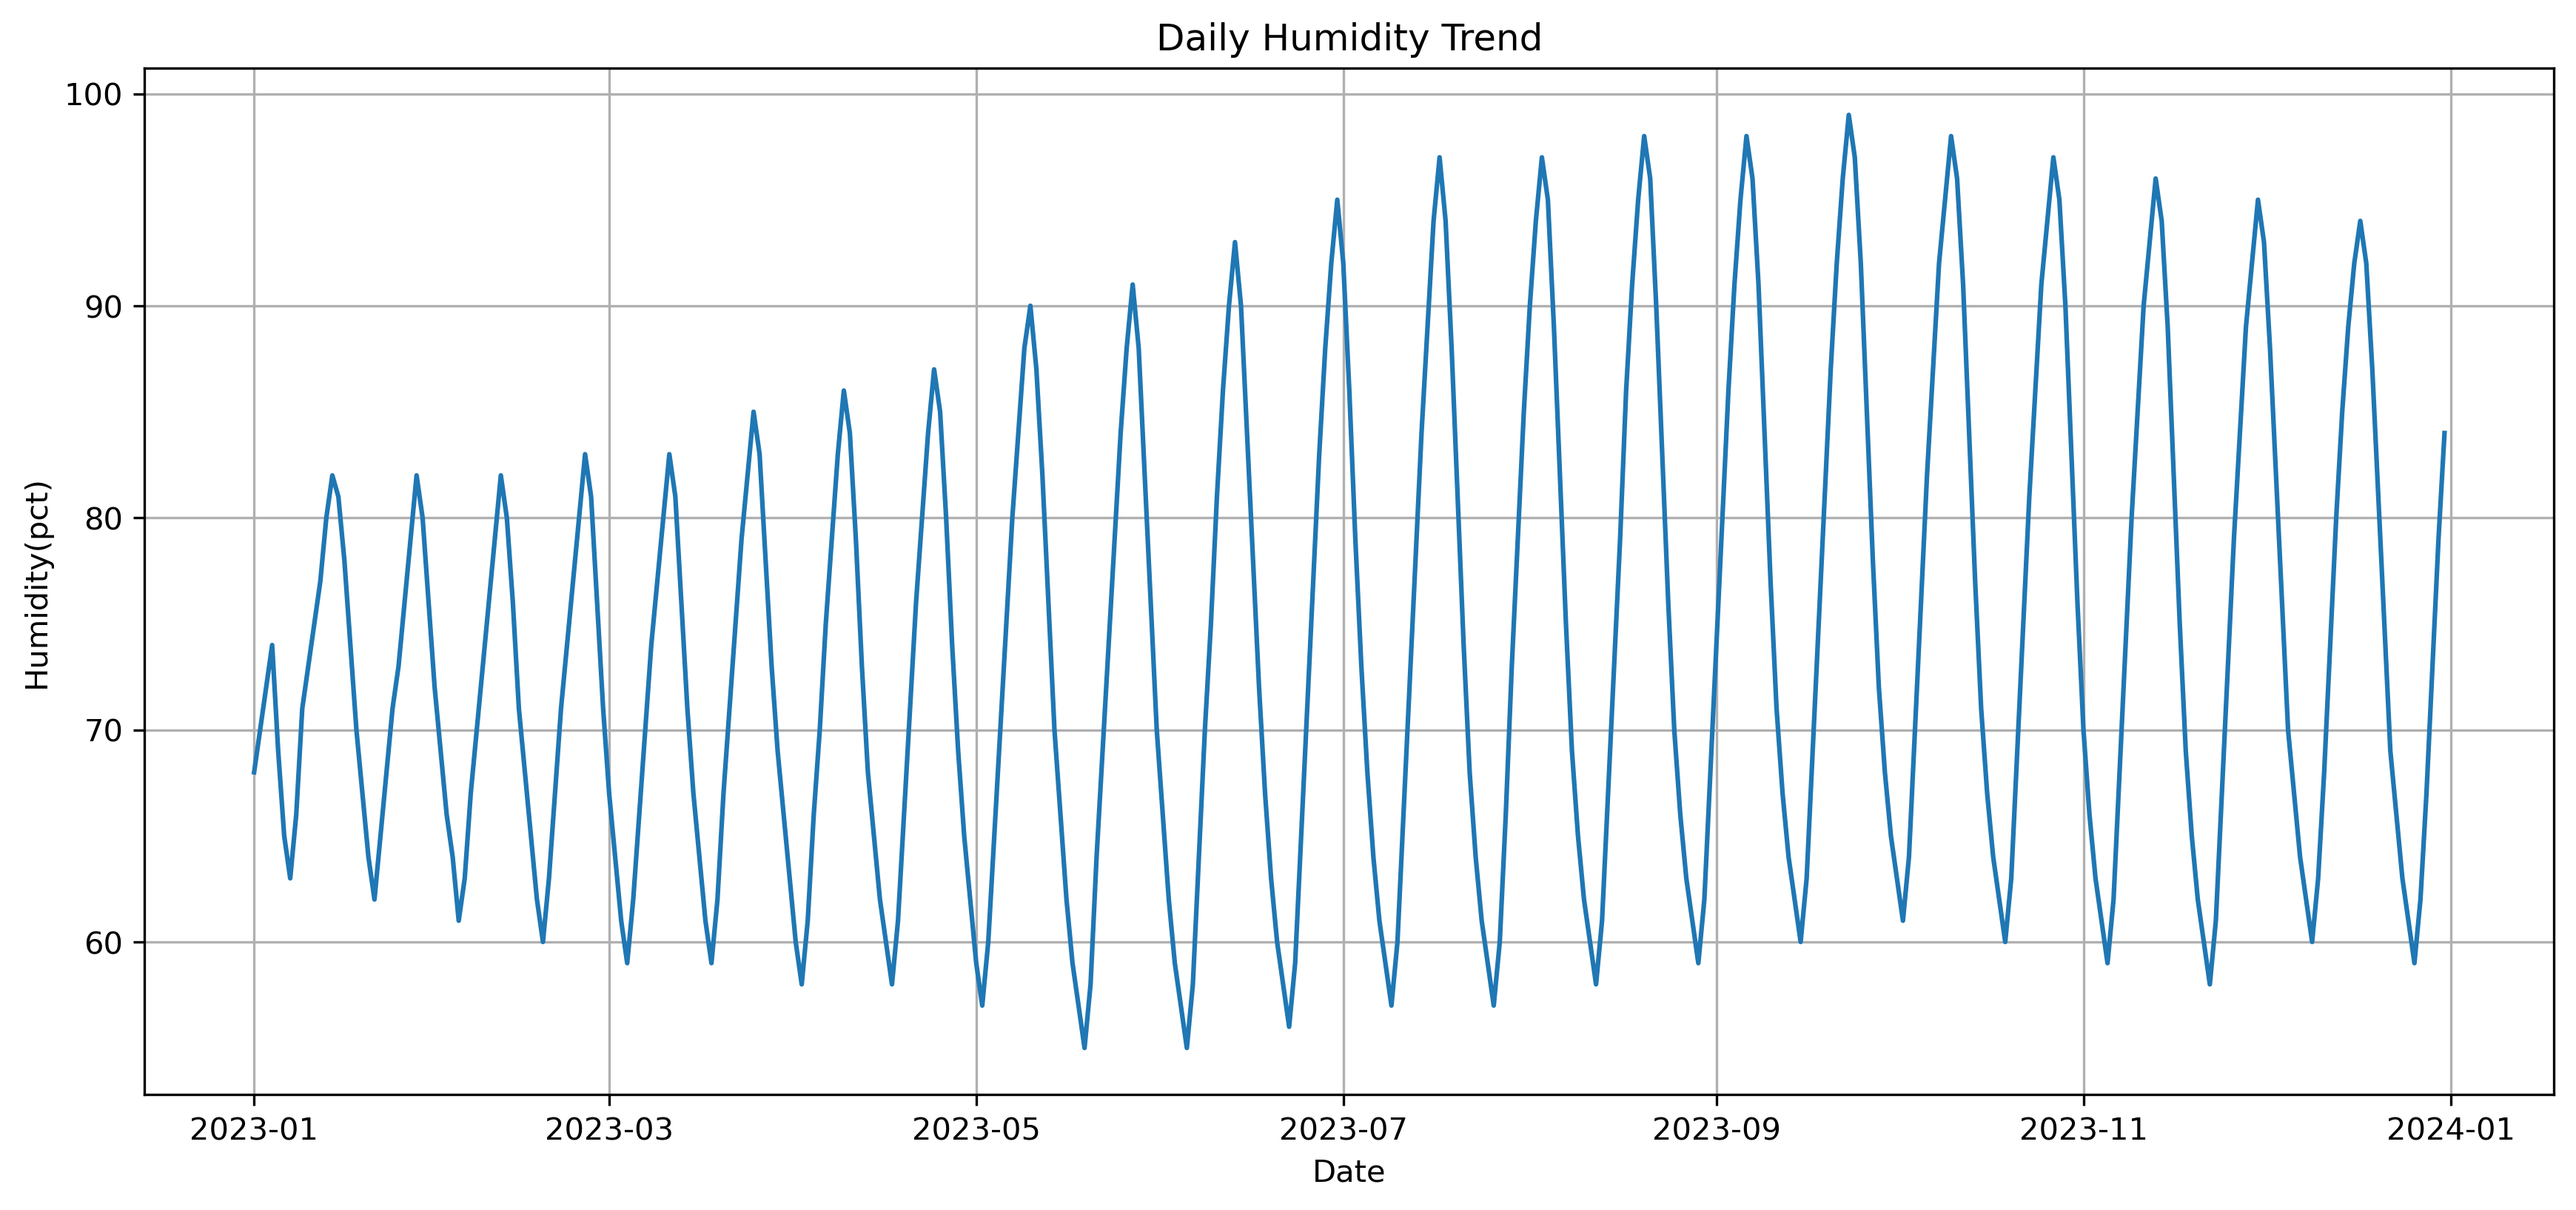

In [10]:
#Temperature Trend Visualization
plt.figure(figsize=(14,6), dpi=300)
plt.plot(df['date'], df['humidity_pct'])
plt.title('Daily Humidity Trend')
plt.xlabel('Date')
plt.ylabel('Humidity(pct)')
plt.grid(True)
plt.show()

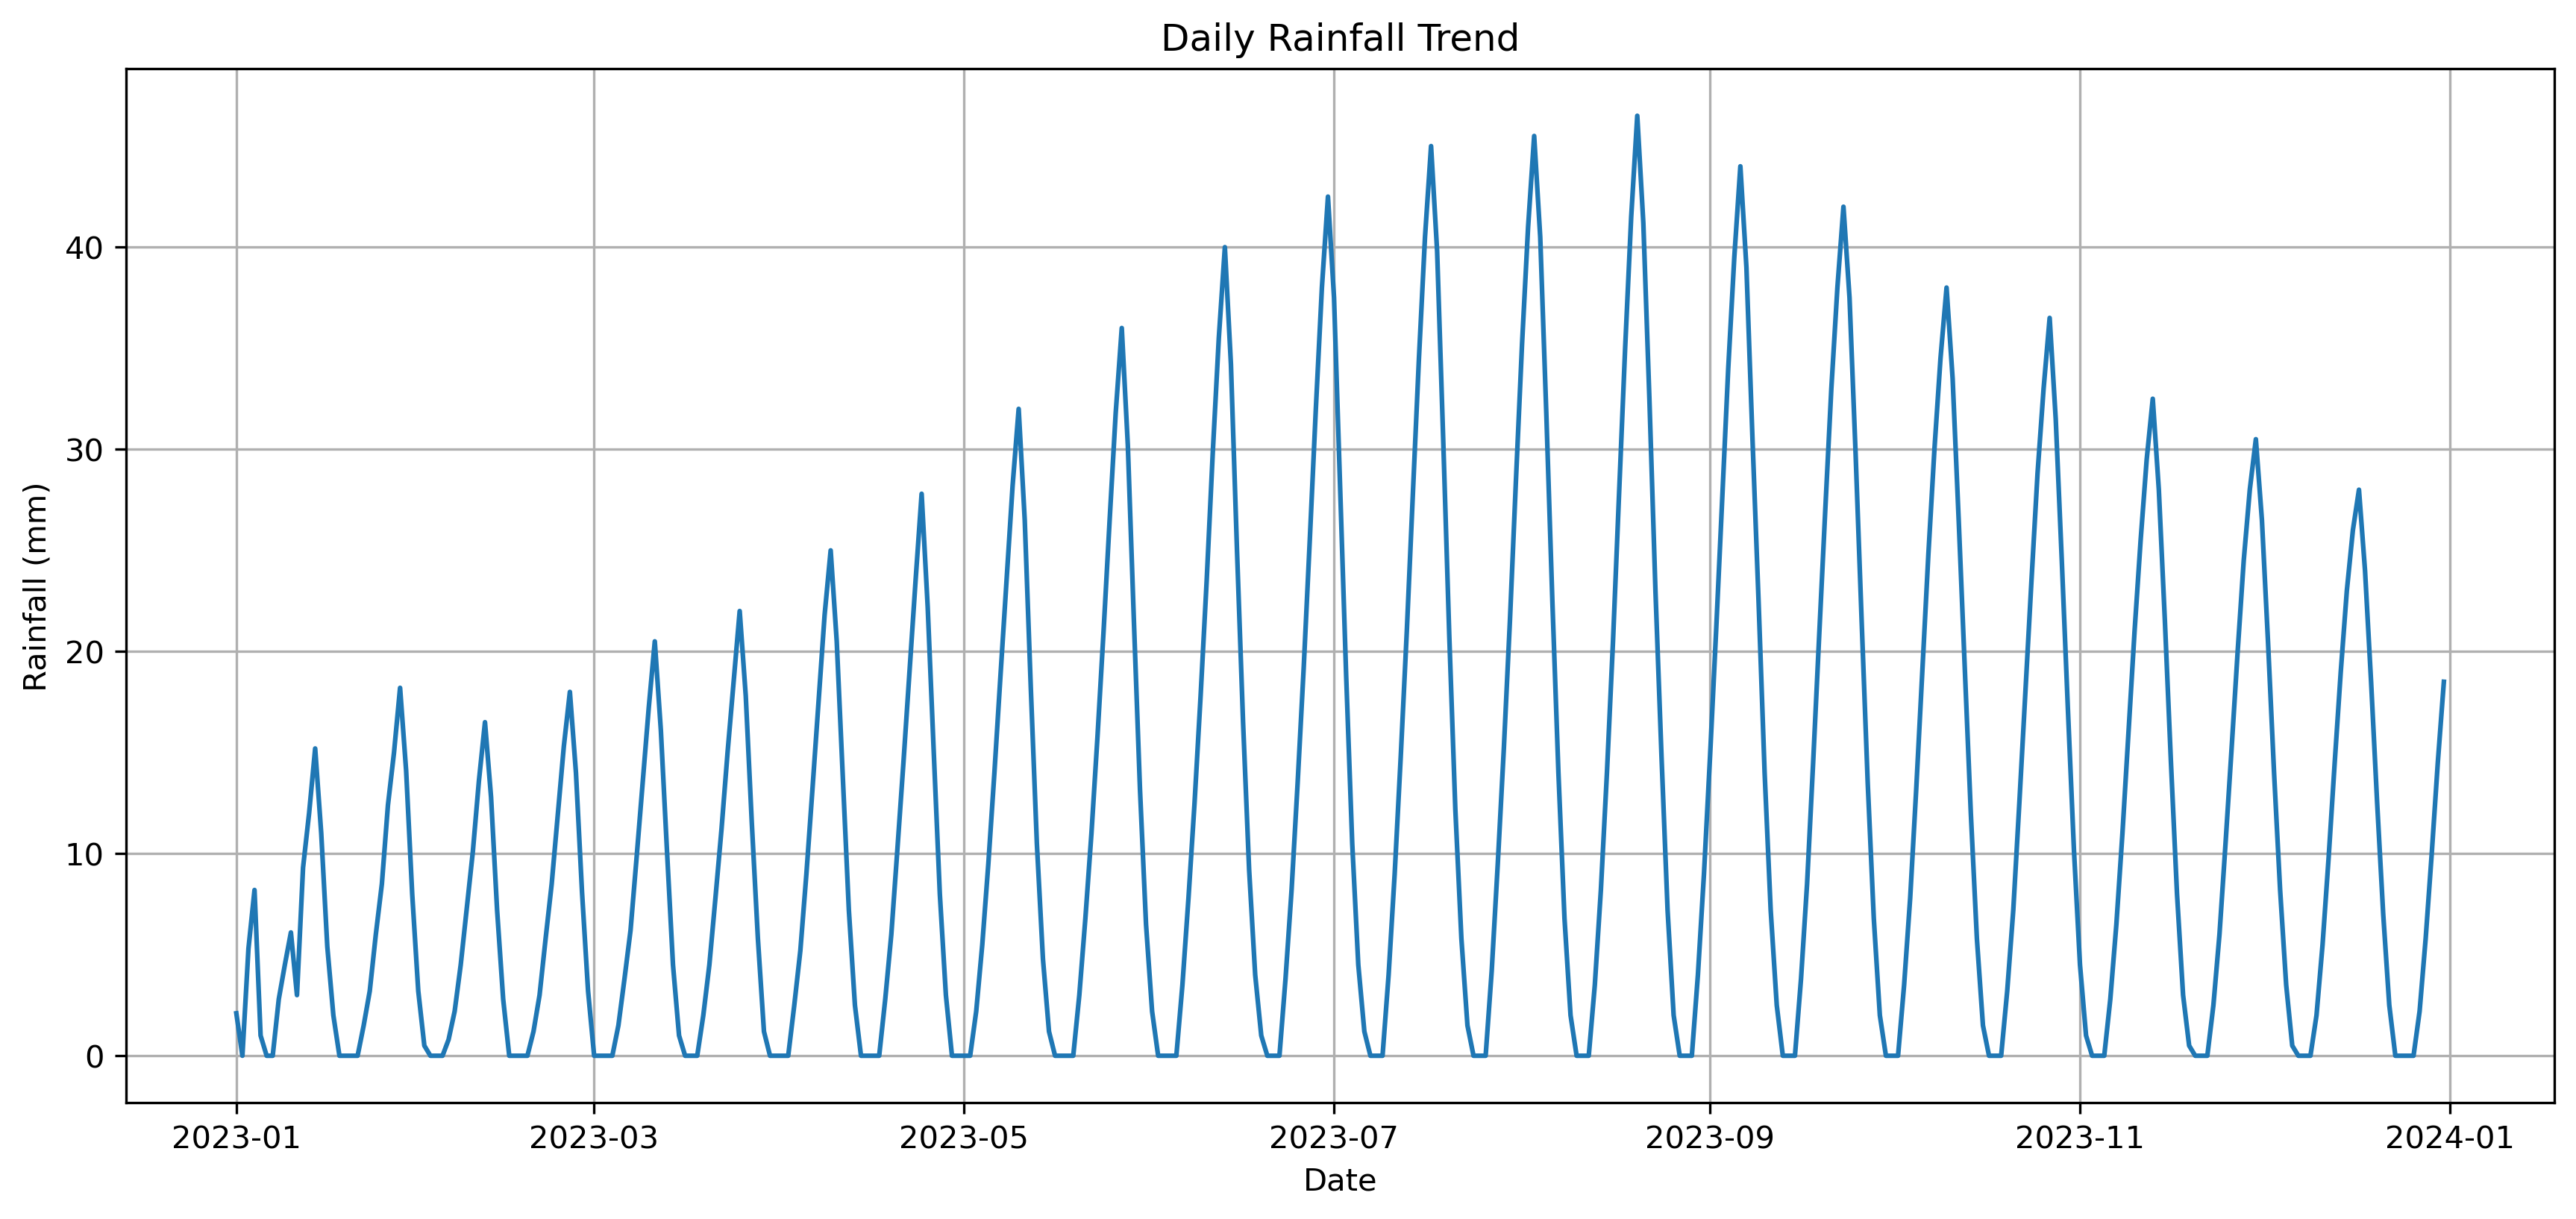

In [11]:
plt.figure(figsize=(14,6), dpi=300)
plt.plot(df['date'], df['rainfall_mm'])
plt.title('Daily Rainfall Trend')
plt.xlabel('Date')
plt.ylabel('Rainfall (mm)')
plt.grid(True)
plt.show()

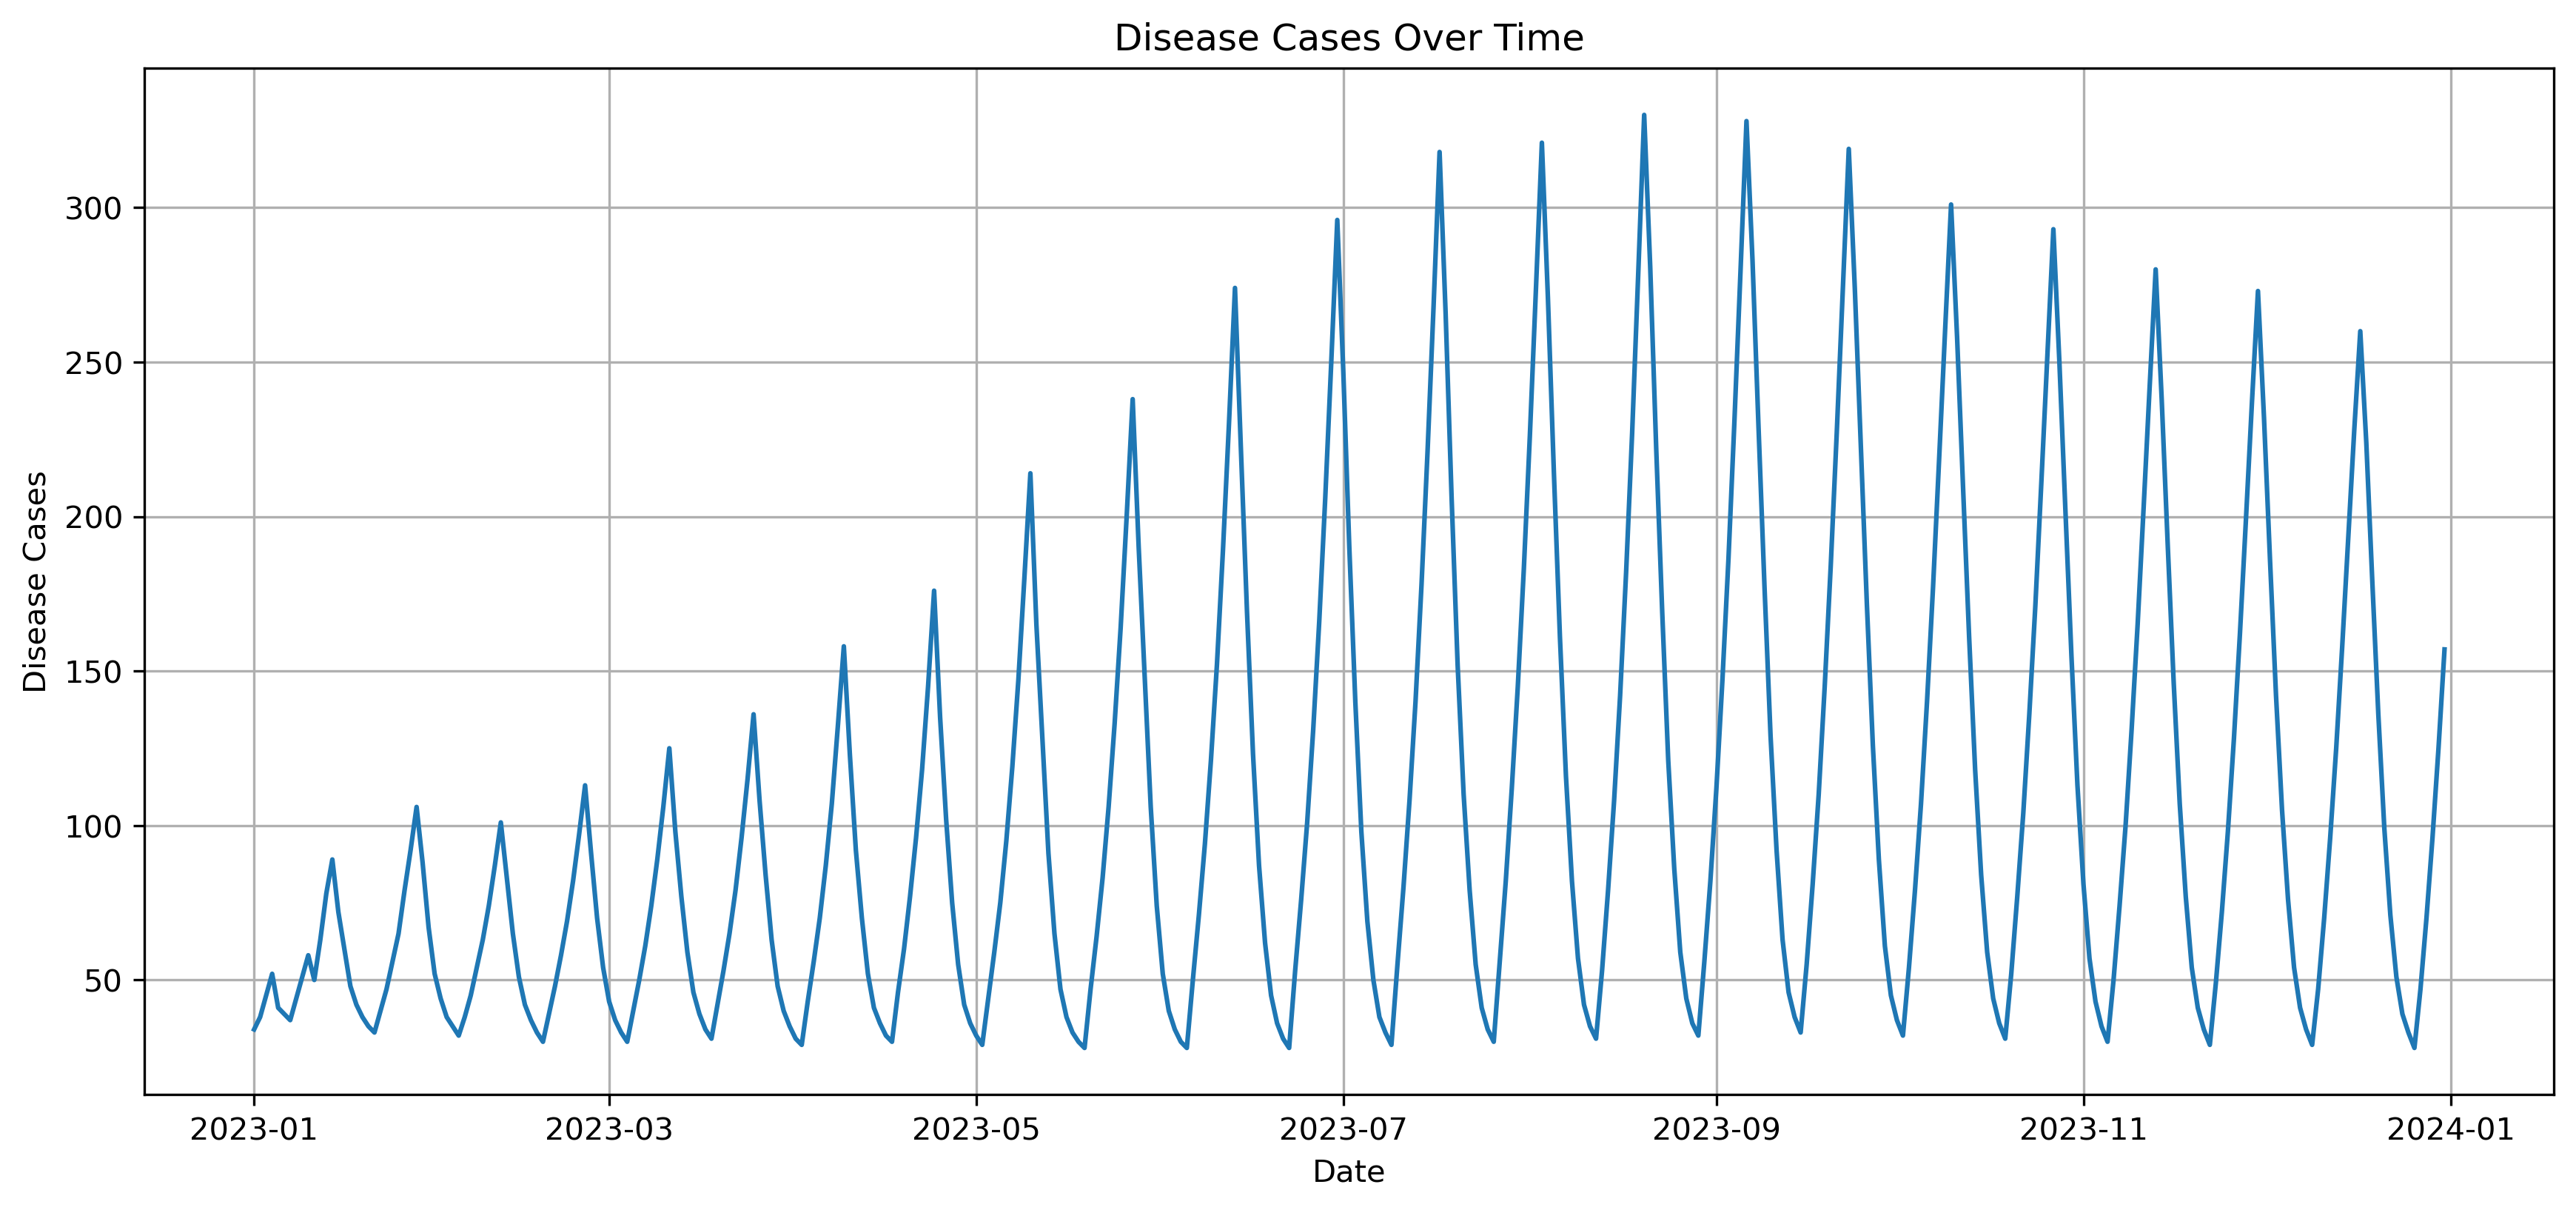

In [12]:
plt.figure(figsize=(14,6), dpi=300)
plt.plot(df['date'], df['disease_cases'])
plt.title('Disease Cases Over Time')
plt.xlabel('Date')
plt.ylabel('Disease Cases')
plt.grid(True)
plt.show()

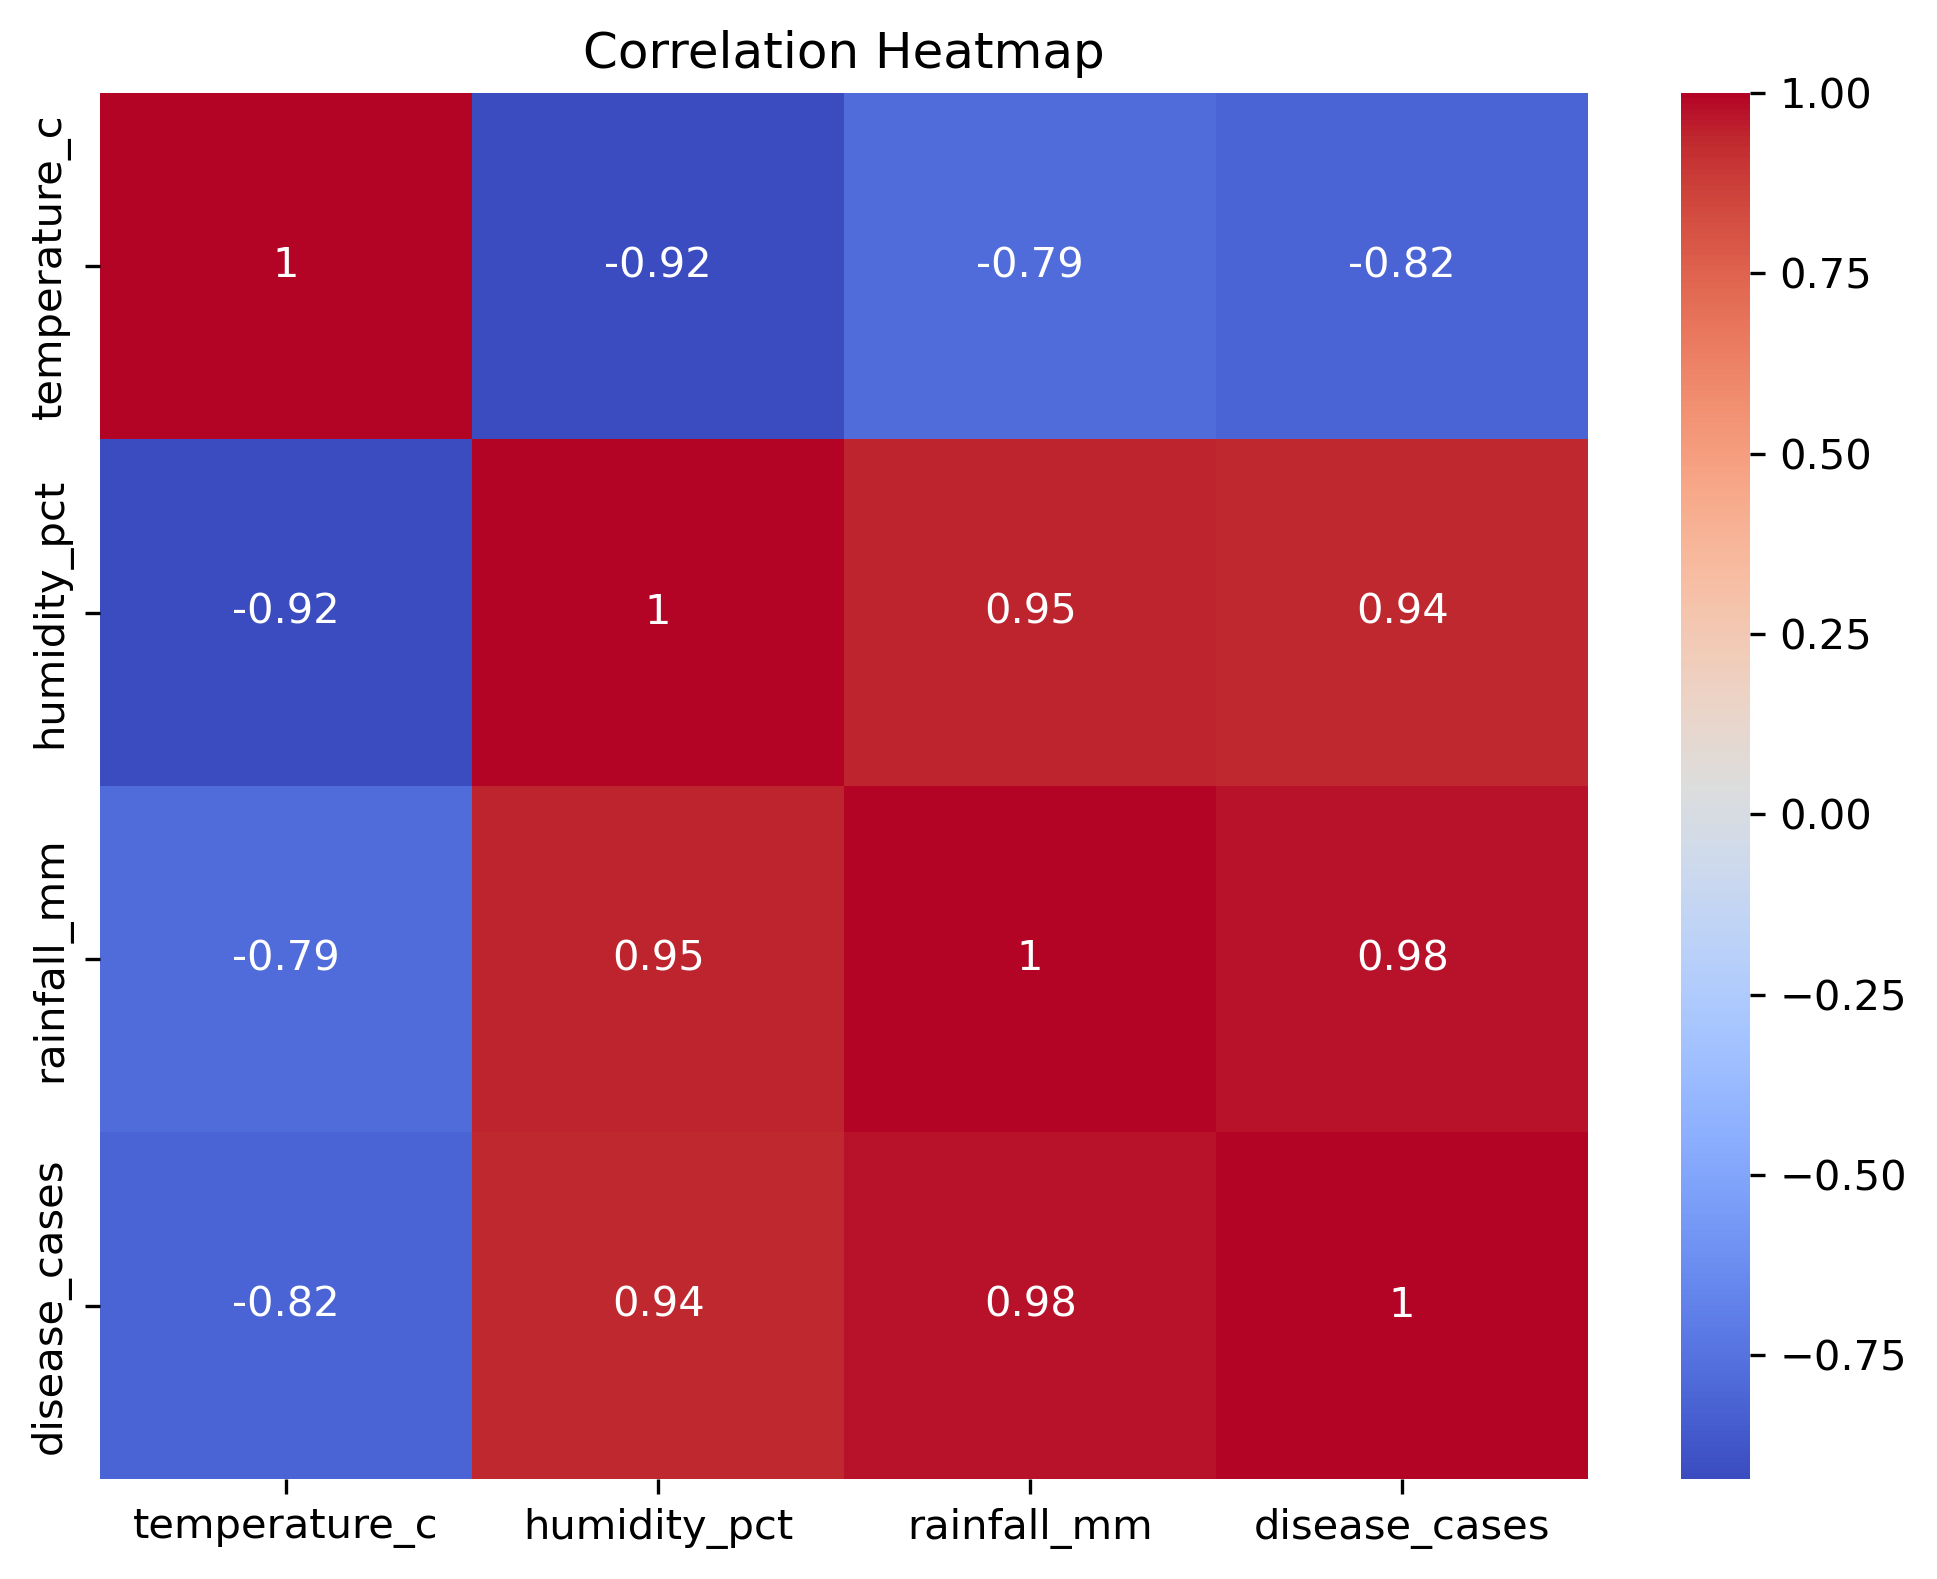

In [13]:
plt.figure(figsize=(8,6), dpi=300)

sns.heatmap(df[['temperature_c', 'humidity_pct',
                'rainfall_mm', 'disease_cases']].corr(),
            annot=True,
            cmap='coolwarm')

# Save image before showing
plt.savefig(
    'correlation_heatmap.png',
    dpi=300,
    bbox_inches='tight'
)
plt.title('Correlation Heatmap')
plt.show()

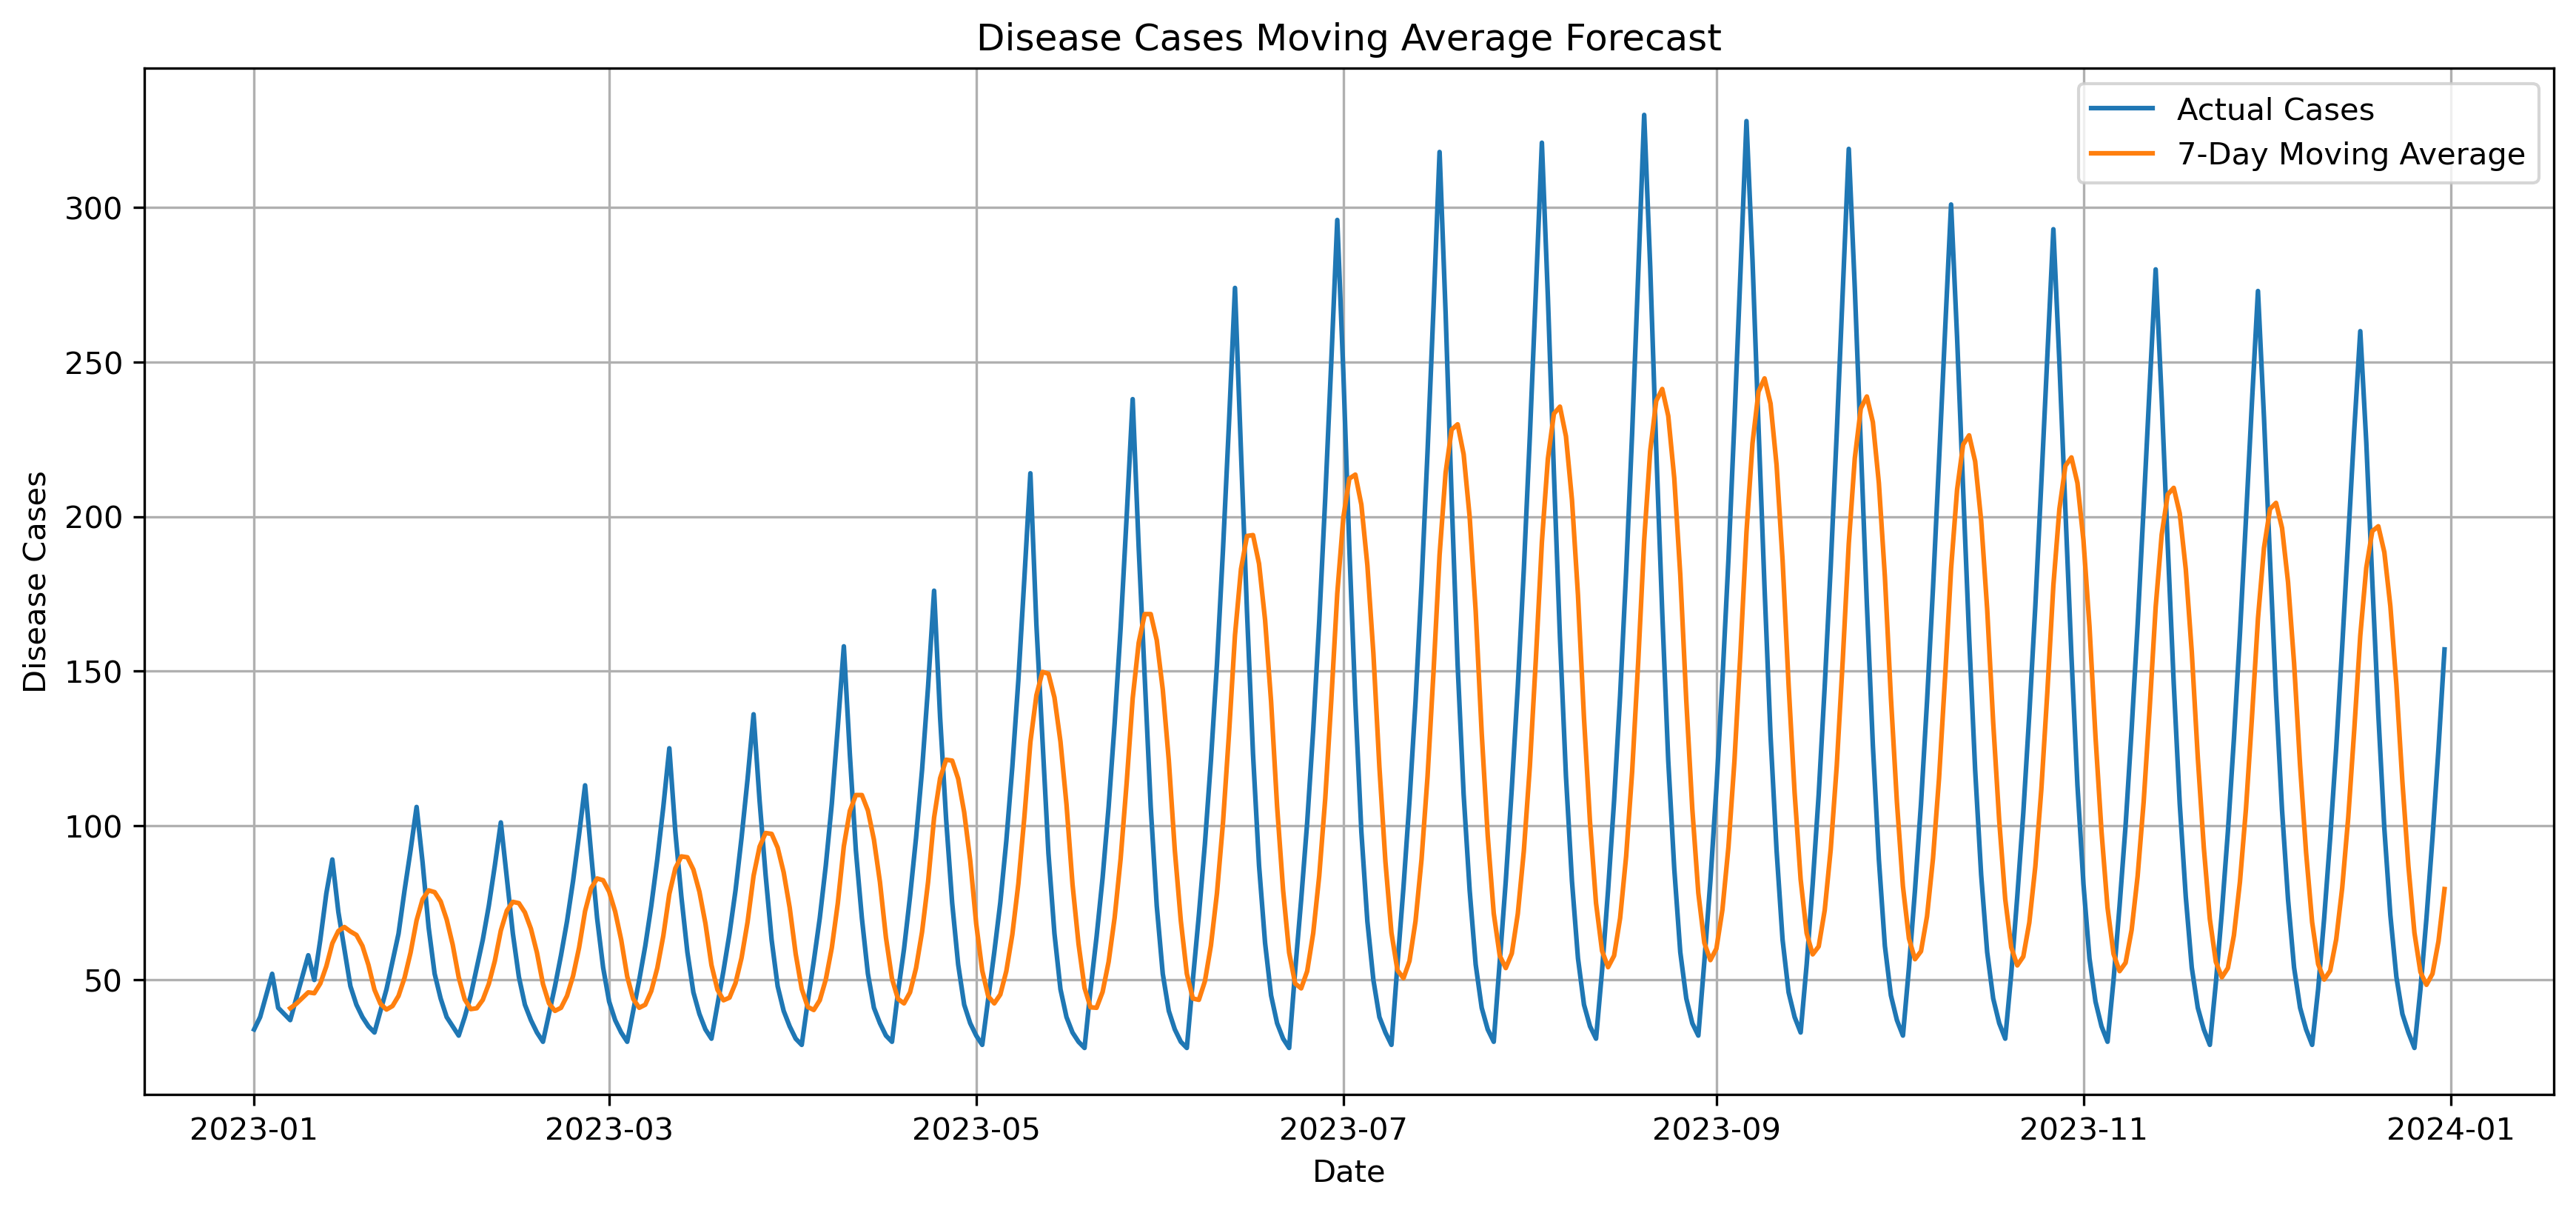

In [14]:
# Create 7-day moving average

df['moving_avg'] = df['disease_cases'].rolling(window=7).mean()

plt.figure(figsize=(14,6), dpi=300)

plt.plot(df['date'], df['disease_cases'], label='Actual Cases')
plt.plot(df['date'], df['moving_avg'], label='7-Day Moving Average')

plt.title('Disease Cases Moving Average Forecast')
plt.xlabel('Date')
plt.ylabel('Disease Cases')
plt.legend()
plt.grid(True)
plt.show()

In [16]:
# Linear Regression Forecasting
from sklearn.linear_model import LinearRegression

# Create time index

df['time_index'] = np.arange(len(df))

X = df[['time_index']]
y = df['disease_cases']

model = LinearRegression()
model.fit(X, y)

# Predictions

df['predicted_cases'] = model.predict(X)

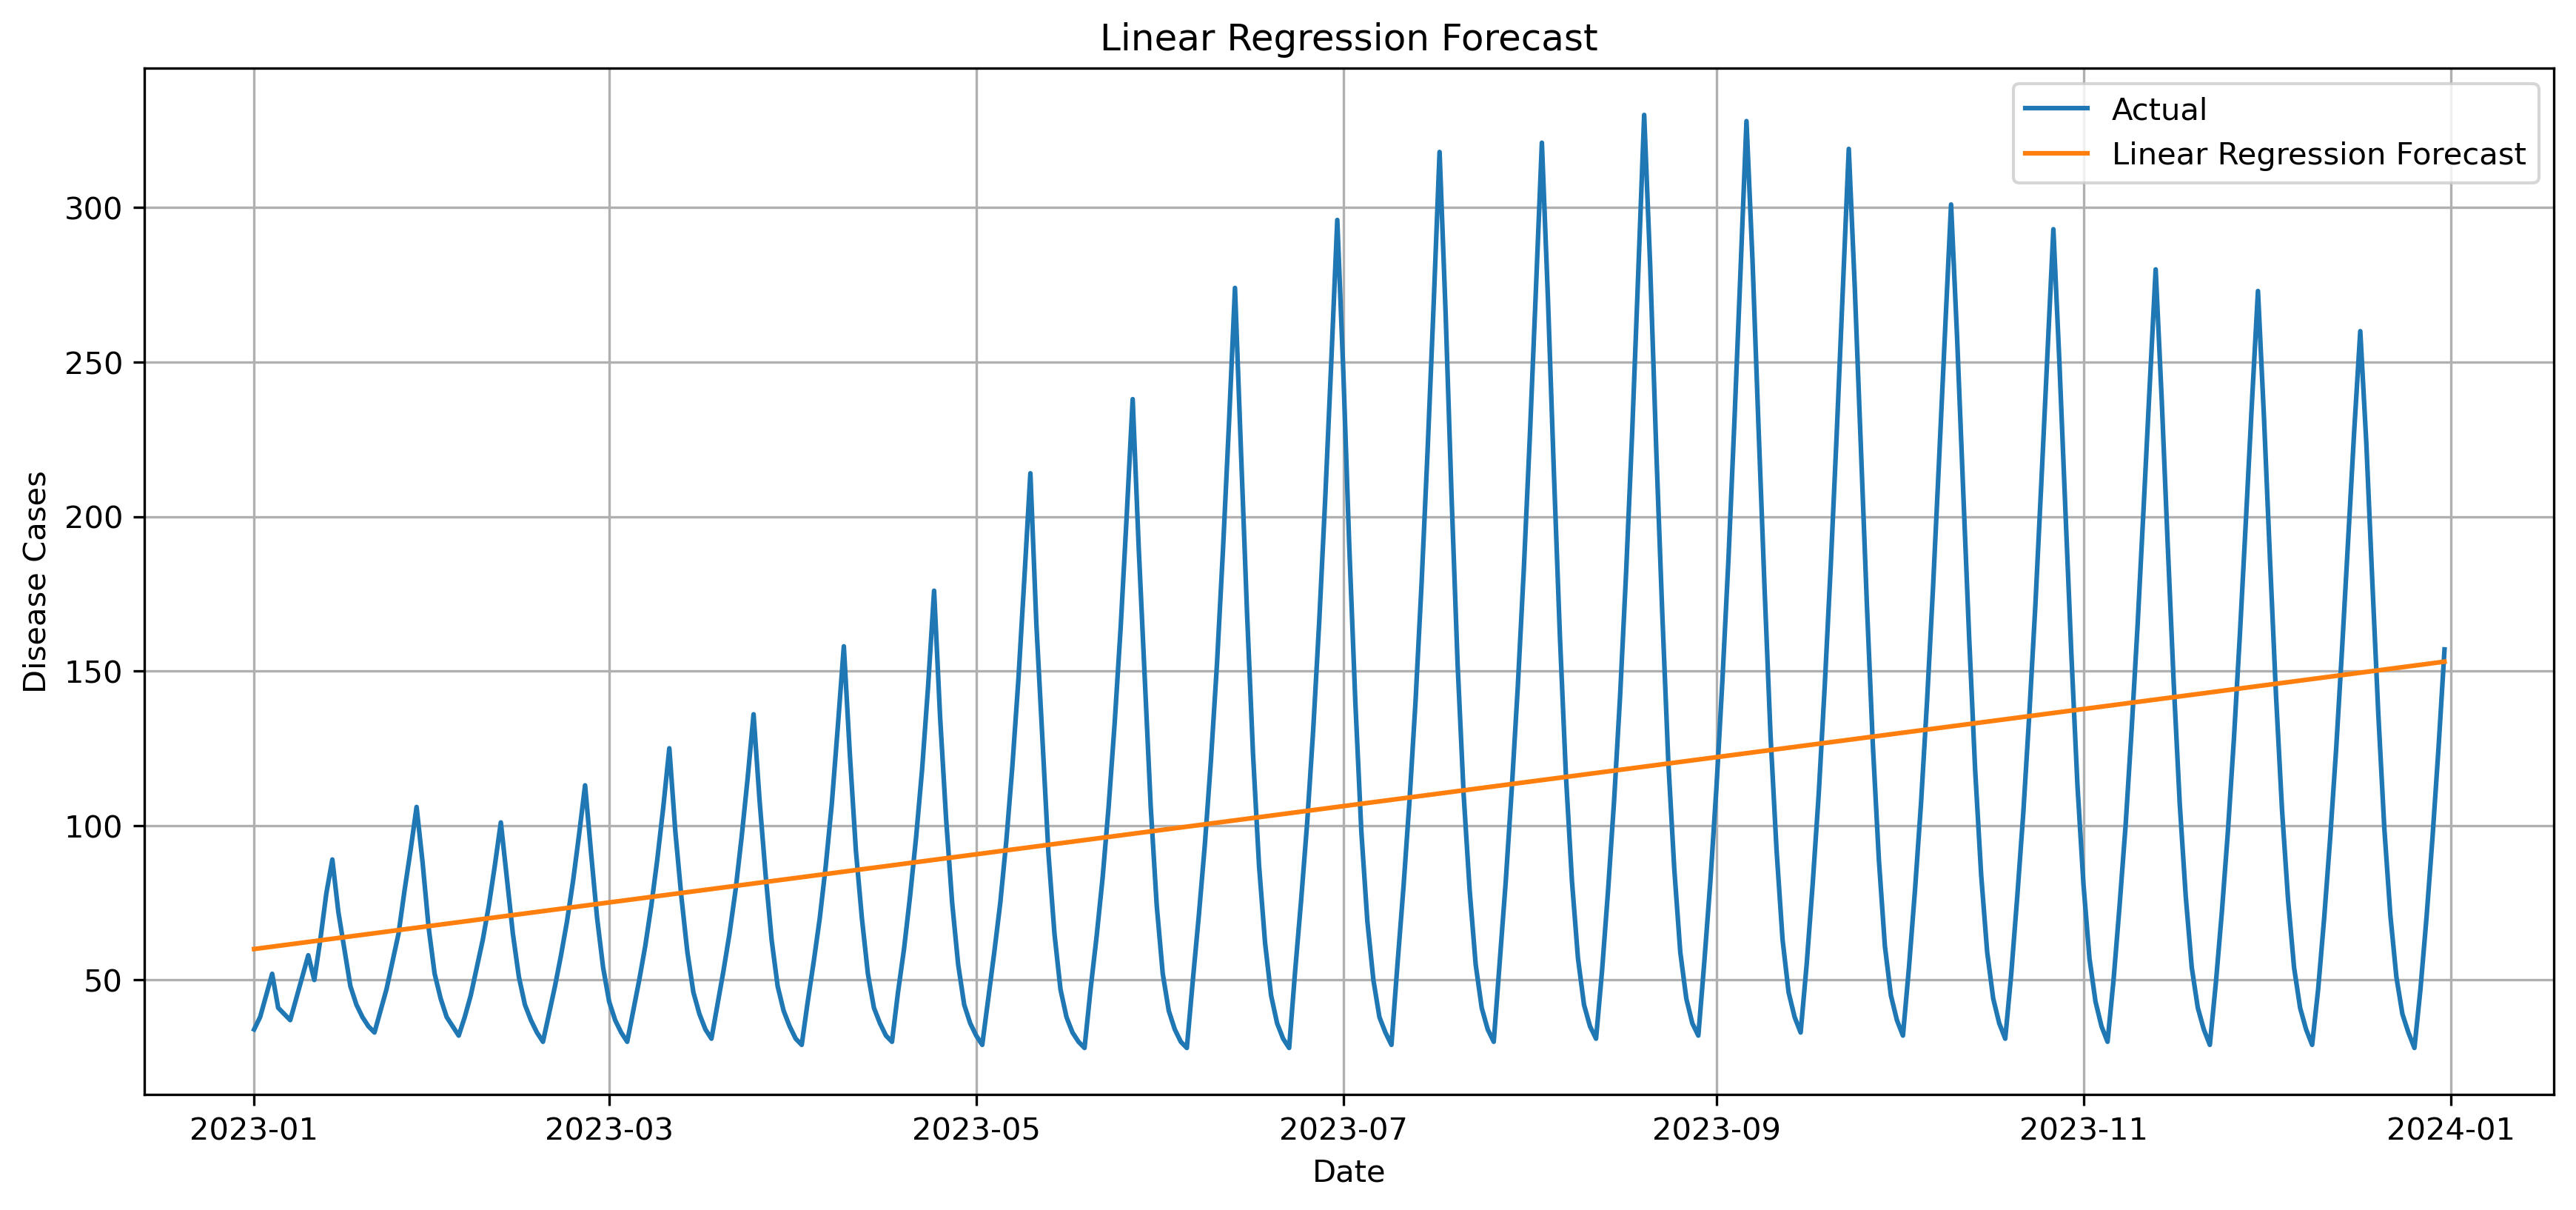

In [17]:
#Visualization of Linear Forecast
plt.figure(figsize=(14,6), dpi=300)

plt.plot(df['date'], df['disease_cases'], label='Actual')
plt.plot(df['date'], df['predicted_cases'],
         label='Linear Regression Forecast')

plt.title('Linear Regression Forecast')
plt.xlabel('Date')
plt.ylabel('Disease Cases')
plt.legend()
plt.grid(True)
plt.show()

In [18]:
#Prophet requires columns named ds and y

prophet_df = df[['date', 'disease_cases']]
prophet_df.columns = ['ds', 'y']

print(prophet_df.head())

          ds   y
0 2023-01-01  34
1 2023-01-02  38
2 2023-01-03  45
3 2023-01-04  52
4 2023-01-05  41


In [22]:
from prophet import Prophet

model = Prophet()
model.fit(prophet_df)

13:43:58 - cmdstanpy - INFO - Chain [1] start processing
13:43:58 - cmdstanpy - INFO - Chain [1] done processing


In [31]:
future = model.make_future_dataframe(periods=30)

forecast = model.predict(future)

print(forecast[['ds', 'yhat']].tail())

            ds        yhat
390 2024-01-26  149.542231
391 2024-01-27  152.068279
392 2024-01-28  151.175536
393 2024-01-29  150.133970
394 2024-01-30  148.549272


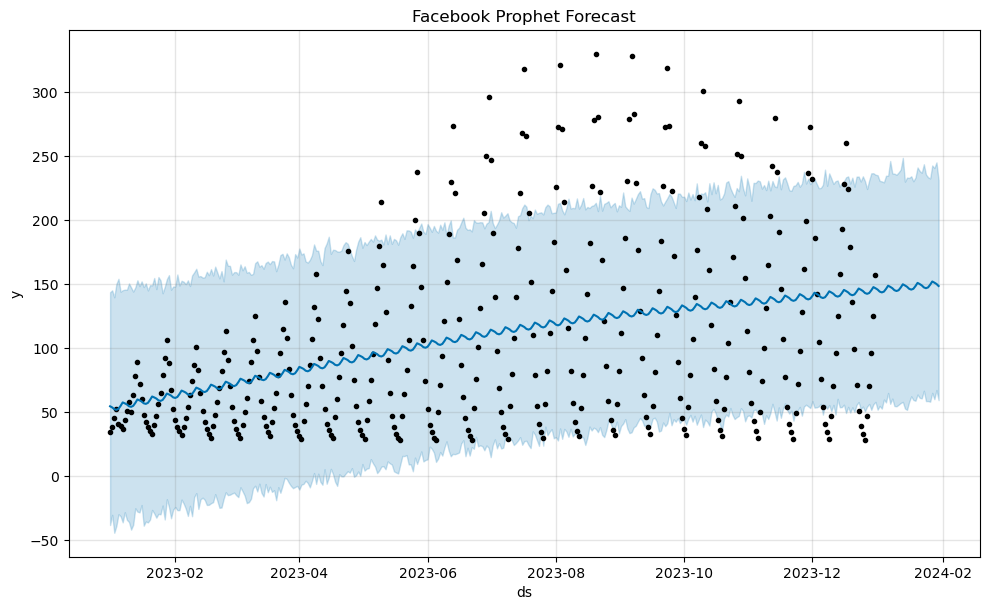

In [44]:
fig1 = model.plot(forecast)
plt.title('Facebook Prophet Forecast')
plt.show()

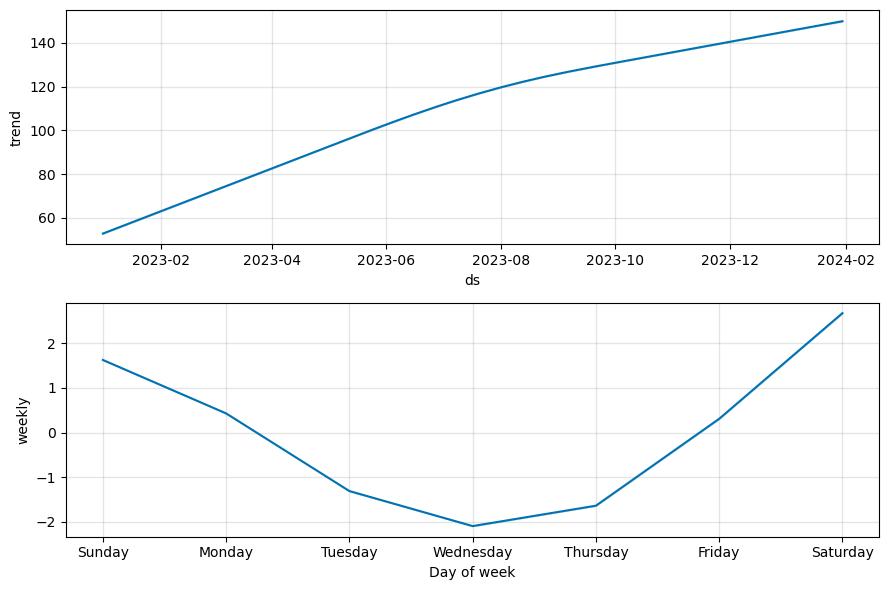

In [39]:
fig2 = model.plot_components(forecast)
plt.show()

In [40]:
from statsmodels.tsa.arima.model import ARIMA

# Build ARIMA model

arima_model = ARIMA(df['disease_cases'], order=(1,1,1))

arima_result = arima_model.fit()

forecast_arima = arima_result.forecast(steps=30)

print(forecast_arima)

365    180.539879
366    196.246244
367    206.725904
368    213.718182
369    218.383595
370    221.496470
371    223.573454
372    224.959267
373    225.883914
374    226.500861
375    226.912502
376    227.187159
377    227.370417
378    227.492690
379    227.574274
380    227.628709
381    227.665029
382    227.689263
383    227.705432
384    227.716221
385    227.723419
386    227.728222
387    227.731427
388    227.733565
389    227.734992
390    227.735944
391    227.736579
392    227.737003
393    227.737285
394    227.737474
Name: predicted_mean, dtype: float64


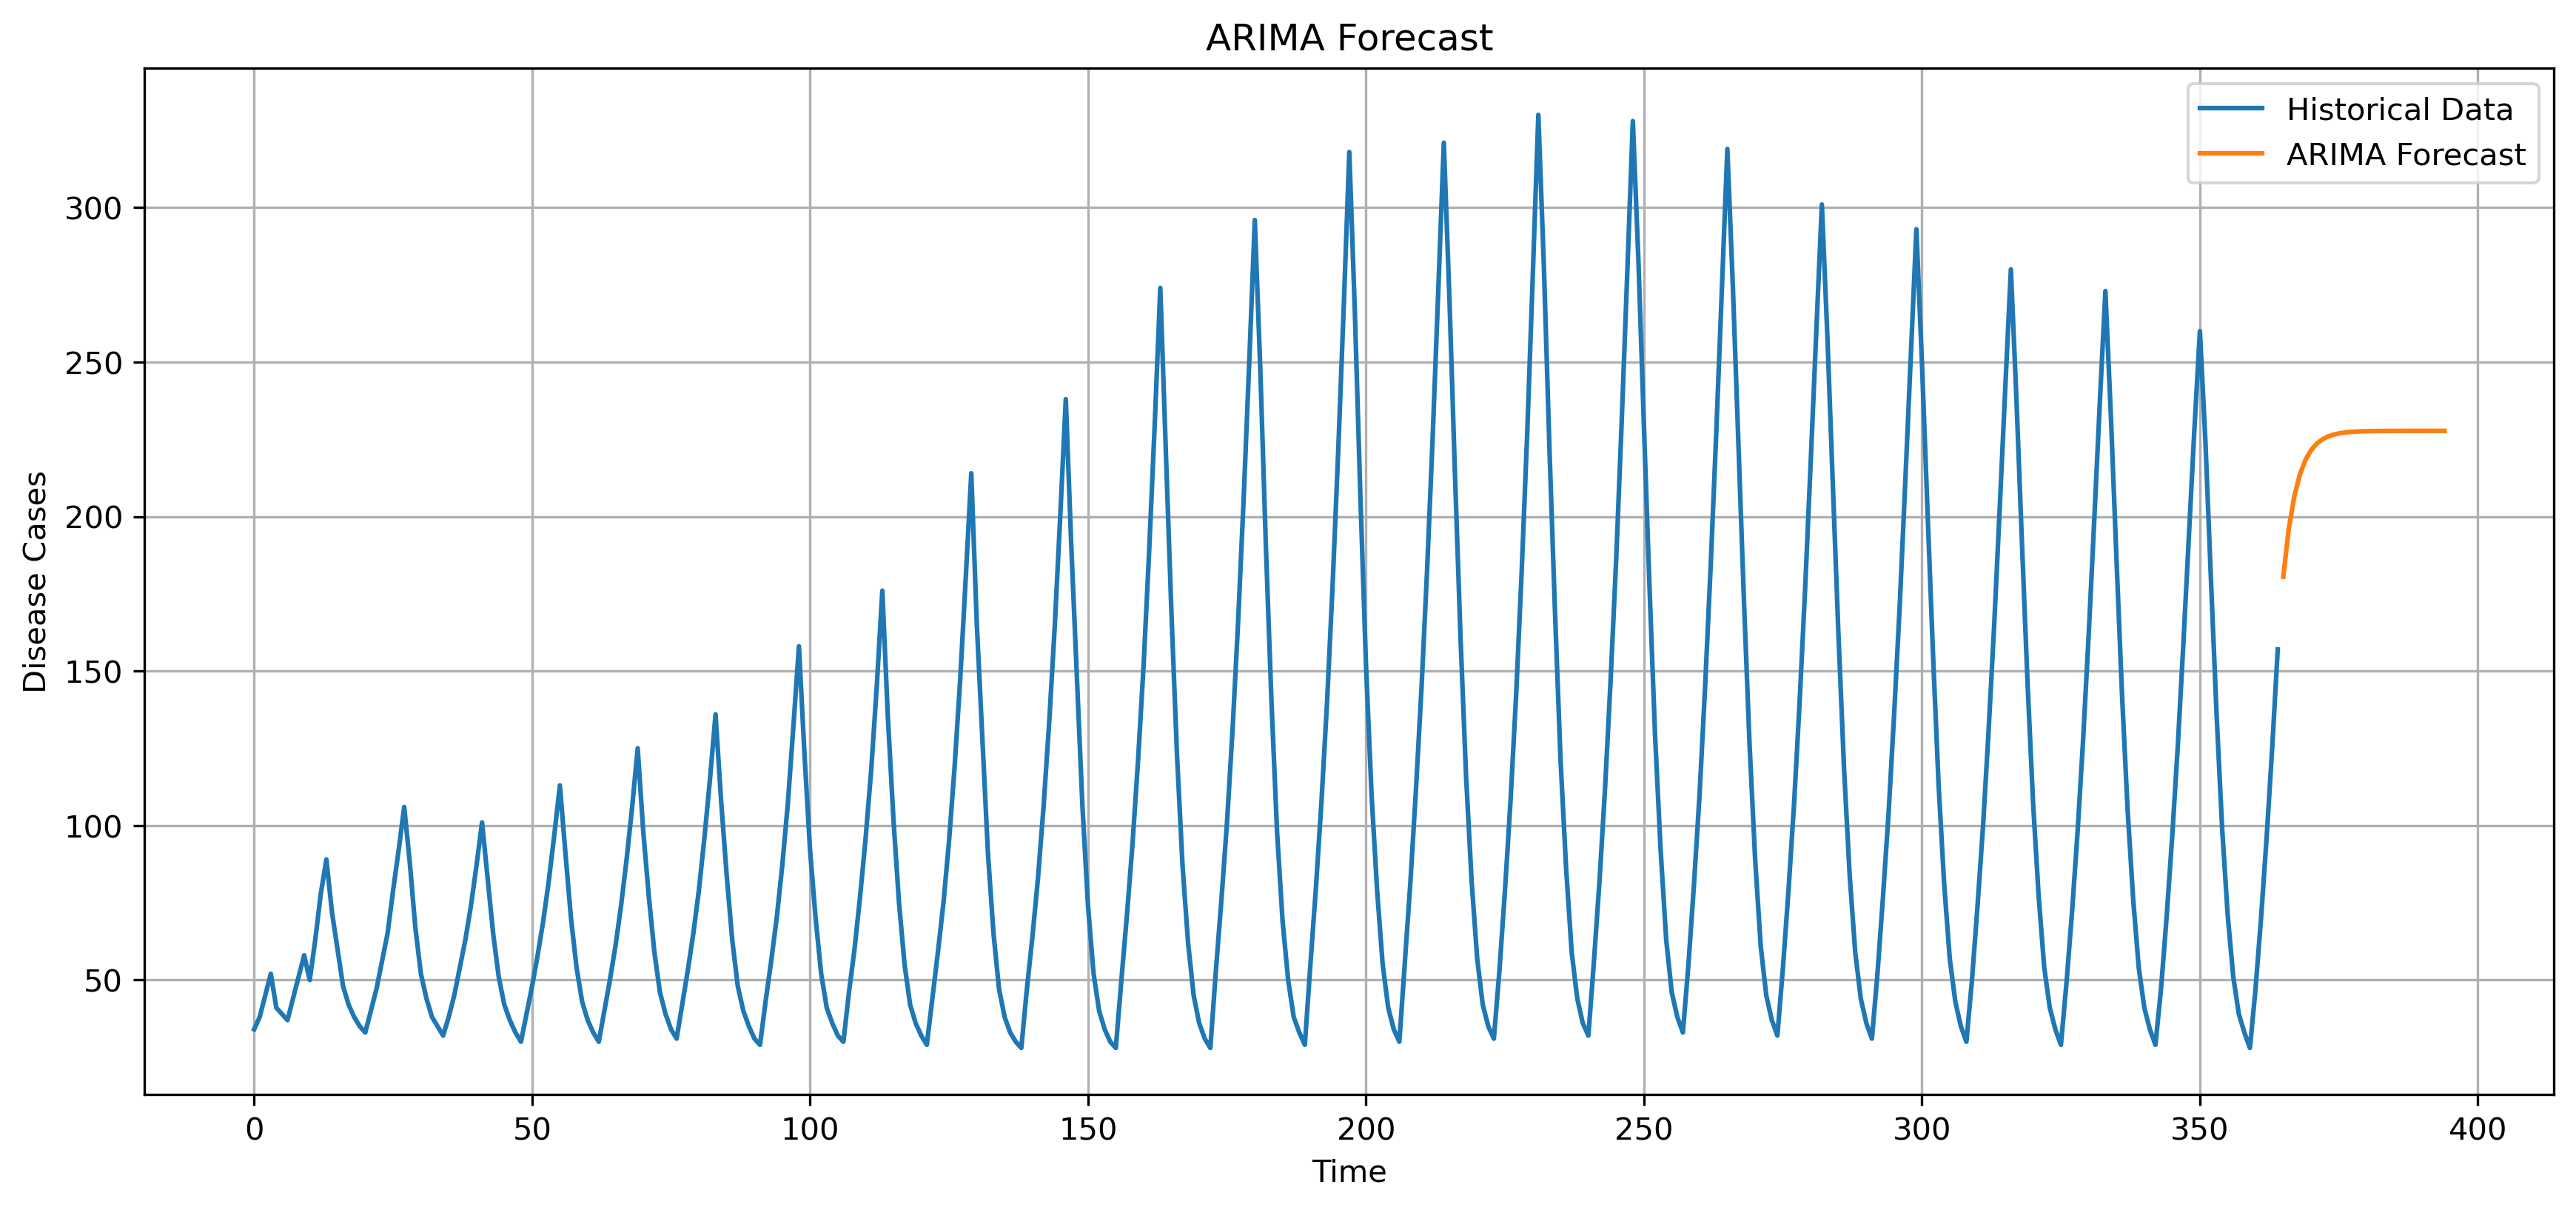

In [41]:
plt.figure(figsize=(14,6), dpi=300)

plt.plot(df['disease_cases'], label='Historical Data')
plt.plot(range(len(df), len(df)+30),
         forecast_arima,
         label='ARIMA Forecast')

plt.title('ARIMA Forecast')
plt.xlabel('Time')
plt.ylabel('Disease Cases')
plt.legend()
plt.grid(True)
plt.show()

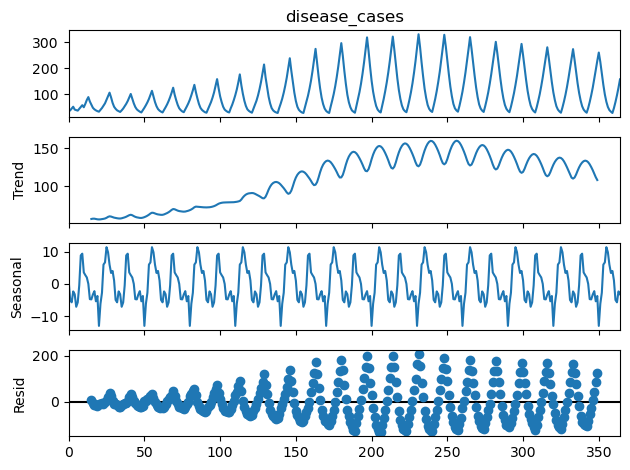

In [42]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(df['disease_cases'],
                            model='additive',
                            period=30)

result.plot()
# Save image before showing
plt.savefig(
    'disease_cases.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

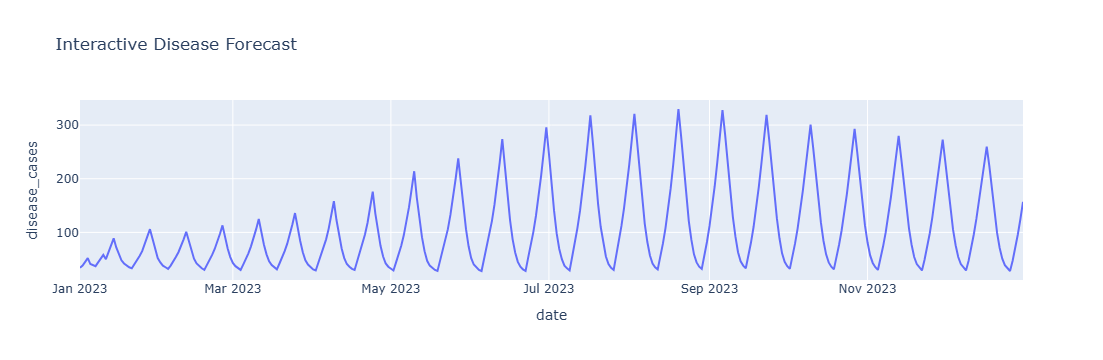

In [43]:
fig = px.line(df,
              x='date',
              y='disease_cases',
              title='Interactive Disease Forecast')

fig.show()

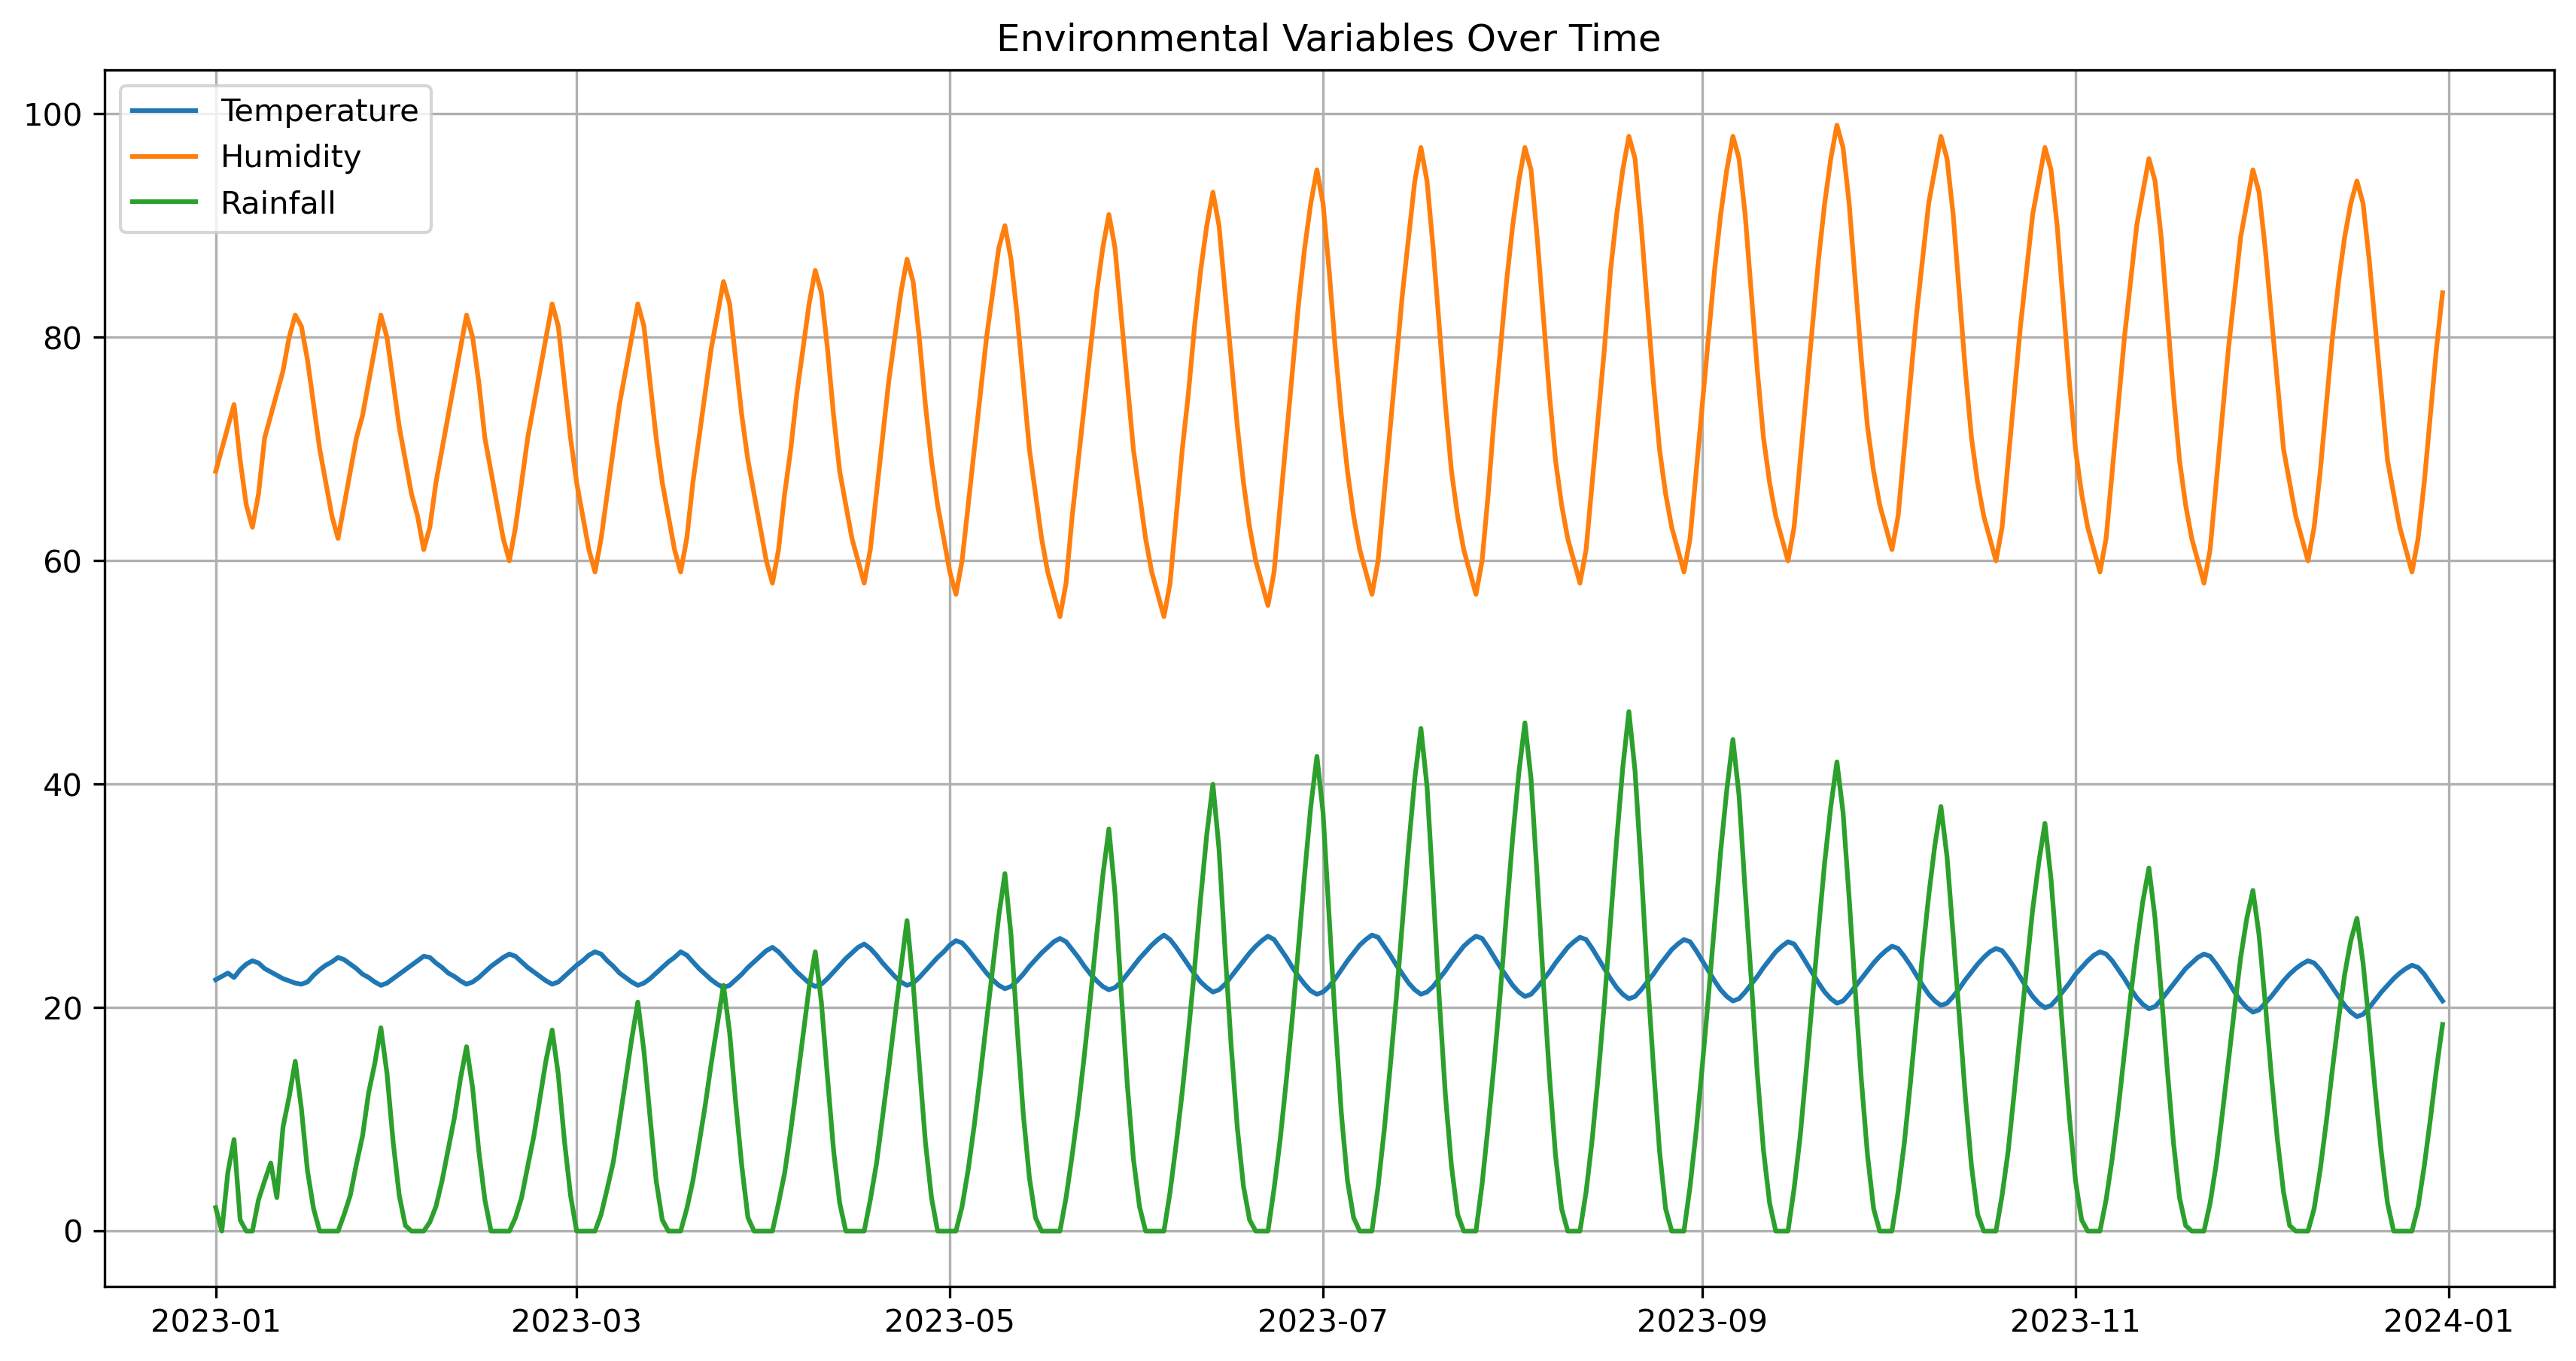

In [45]:
plt.figure(figsize=(14,7), dpi=300)

plt.plot(df['date'], df['temperature_c'], label='Temperature')
plt.plot(df['date'], df['humidity_pct'], label='Humidity')
plt.plot(df['date'], df['rainfall_mm'], label='Rainfall')

plt.legend()
plt.title('Environmental Variables Over Time')
plt.grid(True)
plt.show()

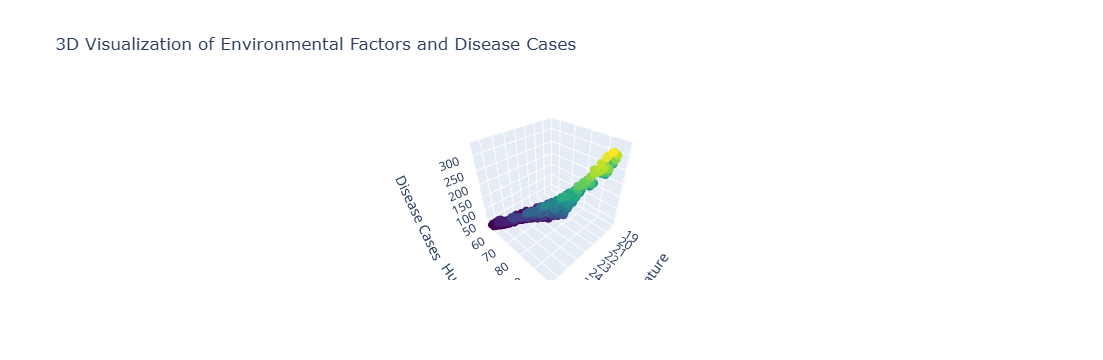

In [46]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Scatter3d(
    x=df['temperature_c'],
    y=df['humidity_pct'],
    z=df['disease_cases'],
    mode='markers',
    marker=dict(
        size=5,
        color=df['rainfall_mm'],
        colorscale='Viridis'
    )
)])

fig.update_layout(
    title='3D Visualization of Environmental Factors and Disease Cases',
    scene=dict(
        xaxis_title='Temperature',
        yaxis_title='Humidity',
        zaxis_title='Disease Cases'
    )
)

fig.show()

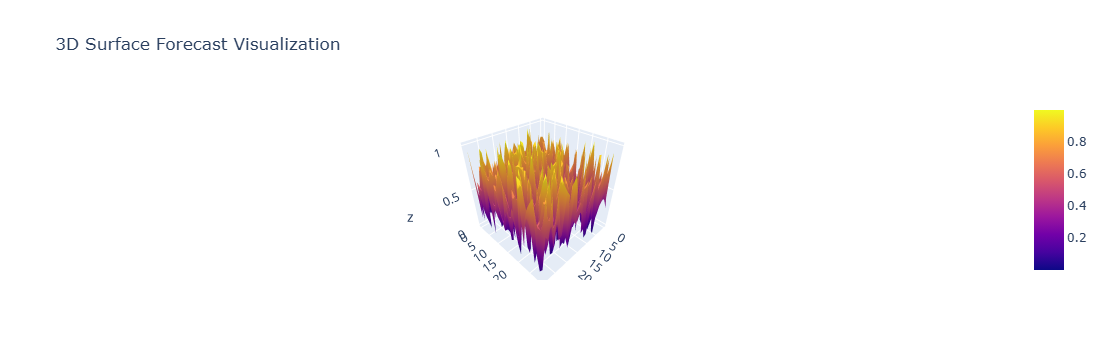

In [47]:
import plotly.graph_objects as go
import numpy as np

z_data = np.random.rand(30,30)

fig = go.Figure(data=[go.Surface(z=z_data)])

fig.update_layout(
    title='3D Surface Forecast Visualization'
)

fig.show()

In [48]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(df['disease_cases'],
                                  df['predicted_cases']))

print('RMSE:', rmse)

RMSE: 70.39863091958867
